# Access and end-use demand figures - Norte Amazonica

Two publication-quality figures. They reuse the print charter of `analyse_resultats.ipynb`
(chapter-5 figures) and the `save_fig()` export helper of `analyse_projections.ipynb`, both in
the neighbouring `EnergyScope_BO_nord_amazonia` repository: same fonts, same 16 cm print width,
same palettes, 300 dpi PNGs - written here to `output/figures/`.

| Figure | File | Content |
|---|---|---|
| 1 | `output/figures/access_by_municipality.png` | Household electricity source by municipality, 2024 census, 21 bars |
| 2 | `output/figures/demand_by_end_use.png` | Annual useful demand by end use, universal sufficiency vs current system |

**Data sources** - no EnergyScope run is read, both figures come from census and RAMP-derived inputs.

* `../exctraction of data/output/CSV_final.csv` - 2001/2012/2024 census, households by
  electricity source. Only the 2024 block is used.
* `../../EnergyScope_BO_nord_amazonia/Data/2025/{sufficiency,reality}/C*/Demands.csv` - the
  useful demand written by the RAMP post-processing notebooks (`../analyse data ramp/*/demande.ipynb`).
  These are model *inputs*, not solver outputs.

---
**Units**: households in dwellings . demand in GWh/year

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

# Same print charter as the chapter-5 figures of analyse_resultats.ipynb and as
# analyse_projections.ipynb: compact 16 cm figures, 300 dpi, no top/right spines.
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10, 'axes.titlesize': 10.5, 'axes.labelsize': 10,
    'legend.fontsize': 8.5, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'axes.spines.top': False, 'axes.spines.right': False,
})
CM = 1 / 2.54

NB_DIR = Path.cwd()                                                  # this folder
BOLIVIA = NB_DIR.parent                                              # bolivia-energy-data
ES_ROOT = (BOLIVIA / '..' / 'EnergyScope_BO_nord_amazonia').resolve()   # RAMP demand handoff
DATA_2025 = ES_ROOT / 'Data' / '2025'
CENSUS_CSV = BOLIVIA / 'exctraction of data' / 'output' / 'CSV_final.csv'

REGIONS = ['C1', 'C2', 'C3', 'C4', 'C5']

# -- PNG export (same charter as save_fig() in analyse_projections.ipynb) -----
FIG_DIR = NB_DIR / 'output' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_DPI = 300
TARGET_WIDTH_CM = 16.0


def save_fig(fig, name):
    """Write one figure to output/figures, at the print charter: 300 dpi,
    tight bounding box, white ground. The exported width is printed, because the
    bounding box is tight and the figure size alone does not determine it."""
    path = FIG_DIR / name
    fig.savefig(path, dpi=EXPORT_DPI, bbox_inches='tight', facecolor='white')
    px = plt.imread(path).shape[1]
    width_cm = px / EXPORT_DPI * 2.54
    flag = '' if abs(width_cm - TARGET_WIDTH_CM) <= 0.6 else '   <-- off target'
    print(f'  written: {path}\n'
          f'           {px} px = {width_cm:.2f} cm at {EXPORT_DPI} dpi{flag}')
    return path


for p in (CENSUS_CSV, DATA_2025):
    assert p.exists(), f'missing path: {p}'
print('Setup OK')
print(f'  census file     : {CENSUS_CSV}')
print(f'  demand inputs   : {DATA_2025}')
print(f'  figure output   : {FIG_DIR}')

Setup OK
  census file     : c:\Valen\Tfe\bolivia-energy-data\exctraction of data\output\CSV_final.csv
  demand inputs   : C:\Valen\Tfe\EnergyScope_BO_nord_amazonia\Data\2025
  figure output   : c:\Valen\Tfe\bolivia-energy-data\analyse_acces_demande\output\figures


---
## 1. Household electricity source by municipality (2024 census)

`CSV_final.csv` carries one row per geographic entity: the region (`Amazonia Norte`), the
departments and provinces, and the 21 municipalities. Only the municipality rows are kept -
a row is a municipality iff `MUNICIPIO/TIOC` is filled - so the province and department rows,
which are aggregates of those same municipalities, are not double counted.

The census splits the 2024 dwellings into five electricity sources. They are grouped into
the three segments of the figure:

| Segment | Census columns |
|---|---|
| Public service | `Servicio publico de energia electrica` |
| Private source | `Motor propio` + `Panel solar` + `Otra` |
| No electricity | `No tiene` |

Two municipalities are named *Santa Rosa* (one in Beni / General Jose Ballivian, one in
Pando / Abuna). They are disambiguated by department, following the `Santa_Rosa_Beni` /
`Santa_Rosa_Pando` convention already used in `../analyse_GIS_phase2_projections/output`.

In [2]:
census = pd.read_csv(CENSUS_CSV)

C24 = 'NÚMERO DE VIVIENDAS POR FUENTE DE ELECTRICIDAD | 2024 | '
COL_TOTAL   = C24 + 'Total'
COL_PUBLIC  = C24 + 'Servicio público de energía eléctrica'
COL_MOTOR   = C24 + 'Motor propio'
COL_SOLAR   = C24 + 'Panel solar'
COL_OTHER   = C24 + 'Otra'
COL_NONE    = C24 + 'No tiene'

# A row is a municipality iff MUNICIPIO/TIOC is filled; the other rows are the region,
# department and province aggregates of those same municipalities.
muni = census[census['MUNICIPIO/TIOC'].notna()].copy()
assert len(muni) == 21, f'expected 21 municipalities, got {len(muni)}'

muni['label'] = muni['MUNICIPIO/TIOC']
dup = muni['label'].duplicated(keep=False)
muni.loc[dup, 'label'] = muni.loc[dup, 'label'] + ' (' + muni.loc[dup, 'DEPARTAMENTO'] + ')'
assert muni['label'].is_unique

acc = pd.DataFrame({
    'public':  muni[COL_PUBLIC].values,
    'private': muni[[COL_MOTOR, COL_SOLAR, COL_OTHER]].sum(axis=1).values,
    'none':    muni[COL_NONE].values,
}, index=muni['label'].values).astype(int)
acc['total'] = acc[['public', 'private', 'none']].sum(axis=1)

# The three segments must exhaust the census total of each municipality.
assert (acc['total'].values == muni[COL_TOTAL].values.astype(int)).all(), \
    'segments do not add up to the census dwelling total'

for c in ['public', 'private', 'none']:
    acc[c + '_pct'] = acc[c] / acc['total'] * 100

acc = acc.sort_values('public_pct', ascending=False)

print('Households by electricity source, 2024 census, 21 municipalities')
print(acc.round(2).to_string())

Households by electricity source, 2024 census, 21 municipalities
                       public  private  none  total  public_pct  private_pct  none_pct
Cobija                  14921      248   395  15564       95.87         1.59      2.54
Guayaramerín             9420      646   825  10891       86.49         5.93      7.58
Riberalta               23121     1396  2925  27442       84.25         5.09     10.66
Porvenir                 1800      217   213   2230       80.72         9.73      9.55
Puerto Gonzalo Moreno    1385      232   348   1965       70.48        11.81     17.71
San Lorenzo              1288      260   302   1850       69.62        14.05     16.32
Reyes                    2353      353   711   3417       68.86        10.33     20.81
Puerto Rico              1344      320   325   1989       67.57        16.09     16.34
Santa Rosa (Pando)        568      143   149    860       66.05        16.63     17.33
Santa Rosa (Beni)        1728      620   407   2755       62.72  

In [3]:
# -- Mandatory control on figure 1 -------------------------------------------
# Pre-registered regional totals. Any gap is reported, never patched.
EXPECTED = {'public': 63495, 'private': 9325, 'none': 11389, 'total': 84209}

sums = {c: int(acc[c].sum()) for c in ['public', 'private', 'none', 'total']}

print('Regional totals computed from the 21 municipality rows')
for k in ['public', 'private', 'none', 'total']:
    d = sums[k] - EXPECTED[k]
    print(f"  {k:<8} {sums[k]:>9,d}   expected {EXPECTED[k]:>9,d}   "
          f"{'OK' if d == 0 else f'GAP {d:+d}  <-- reported, not corrected'}")

# Second, independent control: the census file also carries its own regional
# aggregate row (Amazonia Norte), which never entered the sum above.
reg = census[census['DEPARTAMENTO'] == 'Amazonía Norte'].iloc[0]
reg_sums = {
    'public':  int(reg[COL_PUBLIC]),
    'private': int(reg[COL_MOTOR] + reg[COL_SOLAR] + reg[COL_OTHER]),
    'none':    int(reg[COL_NONE]),
    'total':   int(reg[COL_TOTAL]),
}
print('\nCross-check against the "Amazonía Norte" aggregate row of the census file')
for k in ['public', 'private', 'none', 'total']:
    d = sums[k] - reg_sums[k]
    print(f"  {k:<8} {reg_sums[k]:>9,d}   "
          f"{'OK' if d == 0 else f'GAP {d:+d}  <-- reported, not corrected'}")

Regional totals computed from the 21 municipality rows
  public      63,495   expected    63,495   OK
  private      9,325   expected     9,325   OK
  none        11,389   expected    11,389   OK
  total       84,209   expected    84,209   OK

Cross-check against the "Amazonía Norte" aggregate row of the census file
  public      63,495   OK
  private      9,325   OK
  none        11,389   OK
  total       84,209   OK


  written: c:\Valen\Tfe\bolivia-energy-data\analyse_acces_demande\output\figures\access_by_municipality.png
           1919 px = 16.25 cm at 300 dpi


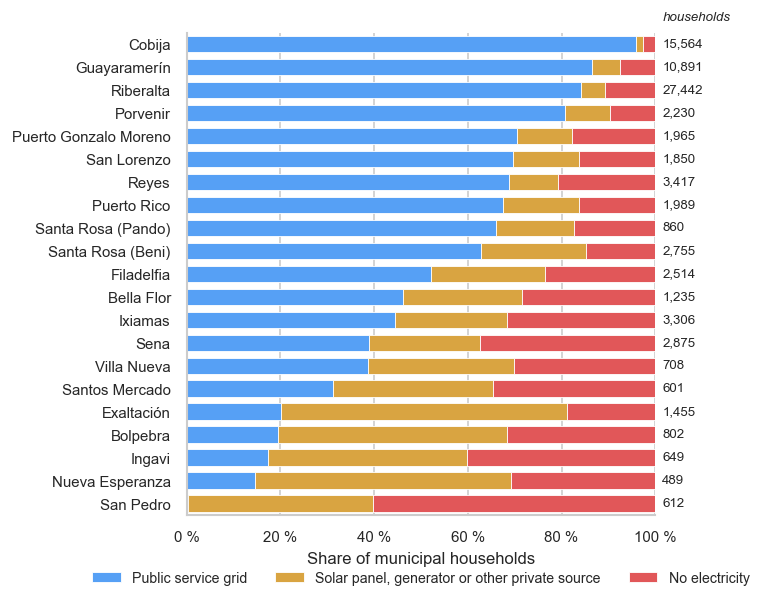

In [4]:
# -- Figure 1: access_by_municipality.png ------------------------------------
# Three contrasted hexes taken from the palettes of analyse_resultats.ipynb:
#   public  = TECH_COLORS['SIN_IMPORT']       grid blue, the colour of grid supply
#   private = SCEN_COLORS['Universal access'] amber, the colour of home systems
#   none    = TECH_COLORS['DEC_DIRECT_ELEC']  red, the most salient of the three
ACCESS_COLORS = {'public': '#56A0F5', 'private': '#D9A441', 'none': '#E15759'}
ACCESS_LABELS = {
    'public':  'Public service grid',
    'private': 'Solar panel, generator or other private source',
    'none':    'No electricity',
}
SEGMENTS = ['public', 'private', 'none']

fig, ax = plt.subplots(figsize=(16 * CM, 13 * CM))

y = np.arange(len(acc))
left = np.zeros(len(acc))
for seg in SEGMENTS:
    v = acc[seg + '_pct'].values
    ax.barh(y, v, 0.72, left=left, color=ACCESS_COLORS[seg], edgecolor='white',
            linewidth=0.5, label=ACCESS_LABELS[seg])
    left = left + v

ax.set_yticks(y)
ax.set_yticklabels(acc.index)
ax.invert_yaxis()                      # highest connected share on top
ax.set_xlim(0, 100)
ax.set_xticks(range(0, 101, 20))
ax.xaxis.set_major_formatter(lambda v, _: f'{v:.0f} %')
ax.set_xlabel('Share of municipal households')
ax.set_ylim(len(acc) - 0.5, -0.5)
ax.grid(axis='y', visible=False)

# Total dwellings of the municipality, to the right of each bar.
for yi, tot in zip(y, acc['total'].values):
    ax.text(101.5, yi, f'{tot:,d}', va='center', ha='left', fontsize=8, clip_on=False)
ax.text(101.5, -1.15, 'households', va='center', ha='left', fontsize=8,
        style='italic', clip_on=False)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.09), ncol=3, frameon=False)

plt.tight_layout()
save_fig(fig, 'access_by_municipality.png')
plt.show()

---
## 2. Useful demand by end use: universal sufficiency vs current system

The useful demand is read from the EnergyScope input files `Data/2025/<scenario>/C*/Demands.csv`,
summed over the five clusters and over the eight demand sectors. These files are the output of
the RAMP post-processing (`../analyse data ramp/sufficiency/demande.ipynb` and
`../analyse data ramp/reality/demande.ipynb`); reading them needs no solved run.

Only the rows in `[GWh]` are kept - the mobility rows are in `[Mpkm]` / `[Mtkm]` and are zero
in this region anyway.

`HEAT_LOW_T_HW` is the input name of the hot-water demand that EnergyScope aggregates into the
`HEAT_LOW_T_DECEN` layer of `analyse_resultats.ipynb`; it takes that layer's colour and is
labelled *Hot water*, since space heating is zero here.

An end use is **named** as soon as it reaches 3 % of the total in *either* of the two pies. It is
then drawn and named in **both**, with the same colour, however small its share in the other one -
so the two pies read segment by segment. Six uses qualify, the three remaining ones are folded
into a single *Other* slice of identical composition in both pies, which takes the neutral
fallback colour `#B0C4D4` of `eud_color()`. Seven slices per pie.

The two rings are **not** drawn at the same size: each radius is proportional to the square root
of its scenario total, so the two disc areas are in the ratio of the demands themselves
(294.2 / 245.1). Ring thickness, label distances and leader anchors are all scaled by the same
radius, so the style is unchanged; both centres stay on y = 0 with identical axis limits, hence
on one horizontal line.

A share below 5 % leaves no room for its label inside the ring, so it is written just outside,
with a leader line; the outside labels are pushed apart vertically when several small slices are
adjacent. Shares under 3 % carry one decimal, because rounding 0.56 % to `1 %` would overstate it.

In [5]:
SECTORS = ['HOUSEHOLDS', 'SERVICES', 'INDUSTRY', 'TRANSPORTATION',
           'PUBLIC_LIGHTING', 'AGRICULTURE', 'MINING', 'FISHING_OTHERS']

SCEN_DEMAND = {'Universal sufficiency': 'sufficiency', 'Current system': 'reality'}


def eud_total(scenario_dir):
    """Useful demand by end use [GWh/yr], summed over the five clusters and all sectors."""
    tot = None
    for r in REGIONS:
        d = pd.read_csv(DATA_2025 / scenario_dir / r / 'Demands.csv', sep=';')
        d = d[d['Units'] == '[GWh]']
        s = d.set_index('parameter name')[SECTORS].sum(axis=1)
        tot = s if tot is None else tot + s
    return tot[tot > 0].sort_values(ascending=False)


demand = {lab: eud_total(d) for lab, d in SCEN_DEMAND.items()}

# Labels and colours: EUD_LABELS / EUD_COLORS of analyse_resultats.ipynb, plus the
# HEAT_LOW_T_HW input name that maps onto the HEAT_LOW_T_DECEN layer.
EUD_LABELS = {
    'COOKING': 'Cooking', 'ELECTRICITY': 'Direct electricity',
    'SPACE_COOLING': 'Space cooling', 'FOOD_PRESERVATION': 'Refrigeration',
    'HEAT_LOW_T_DECEN': 'Low-T heat', 'HEAT_LOW_T_HW': 'Hot water',
    'LIGHTING_R_C': 'Res./com. lighting', 'LIGHTING_P': 'Public lighting',
    'MECHANICAL_ENERGY_COMM': 'Mech. commerce', 'MECHANICAL_ENERGY_IND': 'Mech. industry',
    'MECHANICAL_ENERGY_FIX_AGR': 'Mech. agriculture',
    'MECHANICAL_ENERGY_FISH_OTHERS': 'Mech. fishing',
}
EUD_COLORS = {
    'COOKING':                      '#DA7C7C',
    'ELECTRICITY':                  '#3A81C0',
    'SPACE_COOLING':                '#74C4D8',
    'FOOD_PRESERVATION':            '#6688BE',
    'HEAT_LOW_T_DECEN':             '#D48C60',
    'HEAT_LOW_T_HW':                '#D48C60',
    'LIGHTING_R_C':                 '#C8A84A',
    'LIGHTING_P':                   '#A89050',
    'MECHANICAL_ENERGY_COMM':       '#7B6DC0',
    'MECHANICAL_ENERGY_IND':        '#524A98',
    'MECHANICAL_ENERGY_FIX_AGR':    '#6A9E7A',
    'MECHANICAL_ENERGY_FISH_OTHERS':'#4A9E98',
}
OTHER_COLOR = '#B0C4D4'   # the fallback of eud_color() in analyse_resultats.ipynb


def eud_label(l): return EUD_LABELS.get(l, l)
def eud_color(l): return EUD_COLORS.get(l, OTHER_COLOR)


OTHER_THRESHOLD = 0.03

# Union rule: a use is named as soon as it reaches the threshold in either pie, and is
# then drawn in both. The two pies therefore share one slice list and one Other, whose
# composition is the same on both sides.
share = pd.DataFrame({lab: s / s.sum() for lab, s in demand.items()}).fillna(0)
NAMED = [k for k in demand['Universal sufficiency'].index          # descending sufficiency
         if (share.loc[k] >= OTHER_THRESHOLD).any()]
FOLDED = [k for k in demand['Universal sufficiency'].index if k not in NAMED]
ORDER = NAMED + ['Other']


def to_pie(s):
    """Named uses in the shared order, everything else in one Other slice."""
    out = s.reindex(NAMED)
    out['Other'] = s.reindex(FOLDED).sum()
    return out


pies = {lab: to_pie(s) for lab, s in demand.items()}

EXPECTED_SUFFICIENCY_TOTAL = 245.13   # GWh/yr, pre-registered

for lab, s in demand.items():
    tot = s.sum()
    print(f'== {lab}   total = {tot:.2f} GWh/yr')
    t = pd.DataFrame({'GWh_per_yr': s.round(4), 'share_pct': (s / tot * 100).round(2)})
    t['drawn_as'] = ['named' if k in NAMED else 'Other' for k in s.index]
    t.index = [eud_label(i) for i in t.index]
    print(t.to_string())
    p = pies[lab]
    print(f'   slices drawn: {len(p)}   Other = {p["Other"]:.4f} GWh/yr '
          f'({p["Other"] / tot * 100:.2f} %)')
    print()

print(f'Named in both pies (>= {OTHER_THRESHOLD:.0%} in at least one): '
      f"{', '.join(eud_label(k) for k in NAMED)}")
print(f"Folded into Other in both pies: {', '.join(eud_label(k) for k in FOLDED)}")
print()

d = demand['Universal sufficiency'].sum() - EXPECTED_SUFFICIENCY_TOTAL
print(f'Control: sufficiency total {demand["Universal sufficiency"].sum():.2f} GWh/yr, '
      f'expected {EXPECTED_SUFFICIENCY_TOTAL:.2f} -> '
      f'{"OK" if abs(d) < 0.01 else f"GAP {d:+.3f}  <-- reported, not corrected"}')

== Universal sufficiency   total = 245.13 GWh/yr
                    GWh_per_yr  share_pct drawn_as
Cooking               111.0008      45.28    named
Hot water              71.6684      29.24    named
Refrigeration          29.5851      12.07    named
Space cooling          19.9769       8.15    named
Direct electricity      6.1574       2.51    named
Mech. commerce          3.4388       1.40    Other
Res./com. lighting      1.7017       0.69    Other
Mech. industry          1.3821       0.56    named
Public lighting         0.2156       0.09    Other
   slices drawn: 7   Other = 5.3561 GWh/yr (2.19 %)

== Current system   total = 294.21 GWh/yr
                    GWh_per_yr  share_pct drawn_as
Cooking               112.9688      38.40    named
Space cooling          82.3333      27.98    named
Direct electricity     54.7092      18.60    named
Refrigeration          17.8353       6.06    named
Mech. industry         11.7939       4.01    named
Hot water               5.1014       1.7

Ring radii: Universal sufficiency 0.9128, Current system 1.0000
Area ratio Current system / Universal sufficiency = 1.200229, demand ratio = 1.200229 -> OK
  written: c:\Valen\Tfe\bolivia-energy-data\analyse_acces_demande\output\figures\demand_by_end_use.png
           1891 px = 16.01 cm at 300 dpi


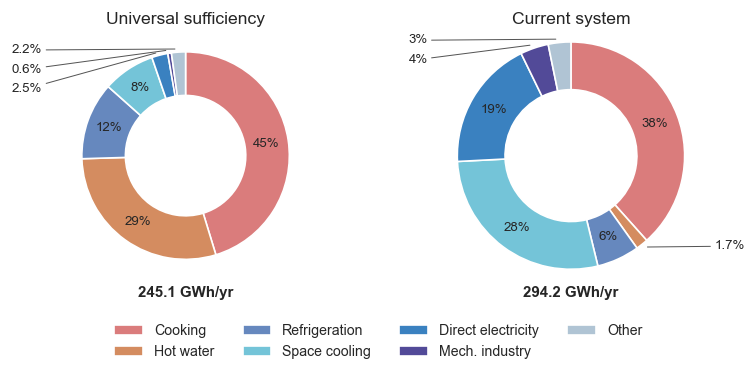

In [6]:
# -- Figure 2: demand_by_end_use.png -----------------------------------------
MIN_INLINE_PCT = 5.0     # below this a share does not fit inside the ring
LEADER_COLOR = '#555555'
OUT_R, TEXT_X, MIN_GAP = 1.03, 1.26, 0.17   # leader start, label column, vertical spacing


def pct_text(p):
    """One decimal below 3 %: rounding 0.56 % to '1 %' would overstate the slice."""
    return f'{p:.1f}%' if p < 3 else f'{p:.0f}%'


def spread(ys, gap=MIN_GAP):
    """Push labels apart, top down, keeping their order."""
    out = list(ys)
    for i in range(1, len(out)):
        out[i] = min(out[i], out[i - 1] - gap)
    return out


def draw_pie(ax, s, r):
    """Donut of the charter at radius `r`, with the shares too small to sit inside
    written outside. Every radial distance is scaled by `r`, so the ring keeps the
    same relative thickness and the labels the same relative placement."""
    pct = s.values / s.values.sum() * 100
    wedges, _ = ax.pie(s.values, colors=[eud_color(k) for k in s.index],
                       startangle=90, counterclock=False, radius=r,
                       wedgeprops={'width': 0.42 * r, 'edgecolor': 'white'})
    outside = []
    for w, p in zip(wedges, pct):
        a = np.deg2rad((w.theta1 + w.theta2) / 2)
        if p >= MIN_INLINE_PCT:
            ax.text(0.79 * r * np.cos(a), 0.79 * r * np.sin(a), pct_text(p),
                    ha='center', va='center', fontsize=8)
        else:
            outside.append((a, p))

    # Outside labels: one column per side, de-overlapped from the top down. The label
    # column stays at a fixed x, so both pies align their labels on the same margin.
    for side in (1, -1):
        grp = [(a, p) for a, p in outside if np.sign(np.cos(a)) == side]
        grp.sort(key=lambda t: -np.sin(t[0]))
        for (a, p), y in zip(grp, spread([np.sin(a) * 1.02 * r for a, _ in grp])):
            ax.annotate(pct_text(p), xy=(OUT_R * r * np.cos(a), OUT_R * r * np.sin(a)),
                        xytext=(TEXT_X * side, y), fontsize=8,
                        ha='left' if side > 0 else 'right', va='center',
                        arrowprops={'arrowstyle': '-', 'lw': 0.6, 'color': LEADER_COLOR,
                                    'shrinkA': 0, 'shrinkB': 2,
                                    'connectionstyle': 'arc3,rad=0'})
    # Identical limits on both axes: same data-to-figure scale, and both centres on
    # y = 0, so the two rings sit on one horizontal line whatever their radius. Just
    # enough room for the leaders; the label text is allowed to spill past the axes,
    # where the tight bounding box of the export picks it up. Widening the limits
    # instead would shrink the donuts, since the equal aspect keeps them circular.
    ax.set_xlim(-1.30, 1.30)
    ax.set_ylim(-1.10, 1.10)


# A pie axis is square while its box is not, so the tight bounding box of the export
# trims the horizontal slack: the canvas is set slightly wider and taller than 16 cm
# so that the *written* PNG lands on the 16 cm charter width (save_fig checks it).
fig, axes = plt.subplots(1, 2, figsize=(16.4 * CM, 7.9 * CM))
# tight_layout does not handle pie axes, whose wedges overflow the axes box:
# the margins are set explicitly so the two totals and the shared legend do not collide.
fig.subplots_adjust(left=0.06, right=0.94, top=0.92, bottom=0.25, wspace=0.30)

# Ring radius proportional to the square root of the scenario total, so the disc
# areas are in the ratio of the demands themselves. The larger total gets radius 1.
TOT_MAX = max(s.sum() for s in pies.values())
RADIUS = {lab: np.sqrt(s.sum() / TOT_MAX) for lab, s in pies.items()}

for ax, (lab, s) in zip(axes, pies.items()):
    draw_pie(ax, s, RADIUS[lab])
    ax.set_title(lab, fontsize=10.5, pad=4)
    ax.text(0.5, -0.02, f'{s.sum():.1f} GWh/yr', transform=ax.transAxes,
            ha='center', va='top', fontsize=9, fontweight='bold')

labs = list(pies)
area_ratio = (RADIUS[labs[1]] / RADIUS[labs[0]]) ** 2
tot_ratio = pies[labs[1]].sum() / pies[labs[0]].sum()
print(f'Ring radii: ' + ', '.join(f'{k} {v:.4f}' for k, v in RADIUS.items()))
print(f'Area ratio {labs[1]} / {labs[0]} = {area_ratio:.6f}, '
      f'demand ratio = {tot_ratio:.6f} -> '
      f'{"OK" if abs(area_ratio - tot_ratio) < 1e-9 else "GAP  <-- reported, not corrected"}')

handles = [mpatches.Patch(facecolor=eud_color(k), edgecolor='white',
                          label='Other' if k == 'Other' else eud_label(k))
           for k in ORDER]
fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, 0.005),
           ncol=4, frameon=False)

save_fig(fig, 'demand_by_end_use.png')
plt.show()